In [3]:
import os
import pickle
import re

import networkx as nx
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [4]:
folder = "data/graphs"

# eigenvector_centrality
for graph in os.listdir(folder):
    filepath = os.path.join(folder, graph)

    # Skip folders
    if not os.path.isfile(filepath):
        continue

    with open(filepath, "rb") as f:
        G = pickle.load(f)
        # print(nx.eigenvector_centrality(G))

In [5]:
abyss_data = pd.read_csv('data/abyss_rank_activity.csv')

In [6]:
base_dir = "data/graphs"


# Extract phase numbers and sort numerically
def extract_phase(filename):
    match = re.search(r"(\d+)", filename)
    return int(match.group(1)) if match else float("inf")


# Get and sort files graph_1.pickle → graph_51.pickle
graph_files = sorted(
    [
        f
        for f in os.listdir(base_dir)
        if f.startswith("graph_") and f.endswith(".pickle")
    ],
    key=extract_phase,
)

# Initialize centrality matrices as dictionaries (phase: {character: score})
degree_matrix = {}
betweenness_matrix = {}
eigenvector_matrix = {}

all_characters = set()

# Load each graph and compute centralities
for file in graph_files[0:]:
    phase = extract_phase(file)  # numeric phase number
    filepath = os.path.join(base_dir, file)

    with open(filepath, "rb") as f:
        G = pickle.load(f)

    # Ensure graph is undirected
    if not isinstance(G, nx.Graph):
        G = nx.Graph(G)

    # Collect all characters in this graph
    nodes = list(G.nodes())
    all_characters.update(nodes)

    # Compute centralities
    # Using weights if available
    degree_cent = nx.degree_centrality(G)  # networkx uses normalized degree centrality

    # Betweenness
    for u, v, data in G.edges(data=True):
        if "weight" in data and data["weight"] != 0:
            data["distance"] = 1.0 / data["weight"]
        else:
            data["distance"] = float("inf")
    betweenness_cent = nx.betweenness_centrality(G, weight="distance", normalized=True)

    eigenvector_cent = nx.eigenvector_centrality(G, weight="weight", max_iter=500)


    # Store values in phase dictionaries
    degree_matrix[phase] = degree_cent
    betweenness_matrix[phase] = betweenness_cent
    eigenvector_matrix[phase] = eigenvector_cent

# Convert to DataFrames
all_characters = sorted(all_characters)  # consistent row ordering
phases = sorted(degree_matrix.keys())  # sorted phase ordering


def build_matrix(matrix_dict, name):
    df = pd.DataFrame(index=all_characters, columns=phases, dtype=float)
    for phase in phases:
        for char in all_characters:
            df.at[char, phase] = matrix_dict.get(phase, {}).get(char, np.nan)
    df.to_csv(f"data/{name}_centrality_matrix.csv")
    return df


degree_df = build_matrix(degree_matrix, "degree")
degree_df.columns = abyss_data['Patch Label'][1:]

betweenness_df = build_matrix(betweenness_matrix, "betweenness")
betweenness_df.columns = abyss_data['Patch Label'][1:]

eigenvector_df = build_matrix(eigenvector_matrix, "eigenvector")
eigenvector_df.columns = abyss_data['Patch Label'][1:]

In [7]:
def raw_cos(a, b):
    # Only consider indices where both a and b are non-null
    common_idx = a.notna() & b.notna()
    
    # Return 0 if no common ratings
    if common_idx.sum() == 0:
        return 0
    
    # Extract the common ratings
    v1 = a[common_idx].values
    v2 = b[common_idx].values
    
    
    # Compute cosine similarity
    numerator = np.dot(v1, v2)
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    
    if denom == 0:
        return 0
    
    return numerator / denom

In [16]:
eig_meta_changes = []
cols = eigenvector_df.columns

for i in range(len(cols) - 1):
    prev_col = cols[i]
    curr_col = cols[i + 1]

    prev_version = eigenvector_df[prev_col]
    curr_version = eigenvector_df[curr_col]

    eig_meta_changes.append(raw_cos(prev_version, curr_version))

eig_meta_dist = np.ones(len(eig_meta_changes))  - eig_meta_changes


In [40]:
cols = ['4.1 I', '4.1 II']

filtered_df = betweenness_df[cols] \
    .dropna() \
    .loc[lambda df: (df != 0).all(axis=1)] \

filtered_df

Patch Label,4.1 I,4.1 II
Bennett,0.292958,0.089336
Eula,0.022938,0.026962
Kaedehara Kazuha,0.391147,0.280080
Kamisato Ayaka,0.000805,0.001207
Kuki Shinobu,0.057143,0.006439
Nahida,0.221328,0.063581
Neuvillette,0.308249,0.874447
Raiden Shogun,0.076861,0.028169
Sangonomiya Kokomi,0.051509,0.021328
Wanderer,0.004829,0.000805


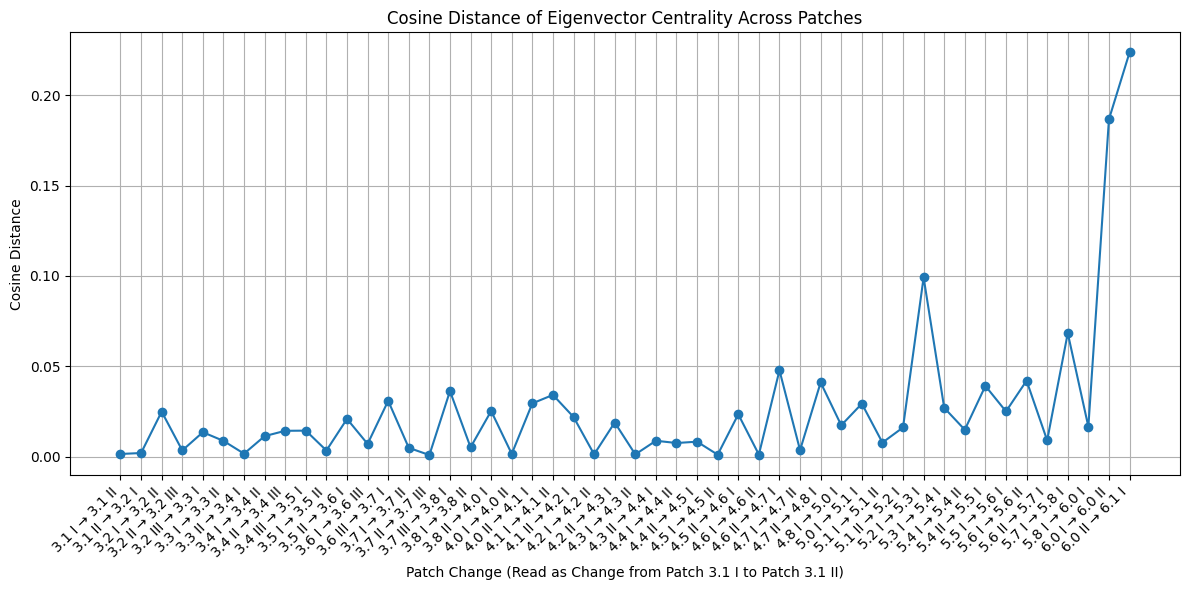

In [17]:
# Then because we are taking the change, we need a differenced
patches = eigenvector_df.columns
change_labels = [f"{patches[i]} → {patches[i+1]}" for i in range(len(patches)-1)]


plt.figure(figsize=(12, 6))
plt.plot(change_labels, eig_meta_dist, marker='o')

plt.title('Cosine Distance of Eigenvector Centrality Across Patches')
plt.xlabel('Patch Change (Read as Change from Patch 3.1 I to Patch 3.1 II)')
plt.ylabel('Cosine Distance')
plt.grid(True)

# Apply Patch_Labeled as tick labels
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [20]:
betwenness_meta_changes = []
cols = betweenness_df.columns

for i in range(len(cols) - 1):
    prev_col = cols[i]
    curr_col = cols[i + 1]

    prev_version = betweenness_df[prev_col]
    curr_version = betweenness_df[curr_col]

    betwenness_meta_changes.append(raw_cos(prev_version, curr_version))

betwenness_meta_dist = np.ones(len(betwenness_meta_changes))  - betwenness_meta_changes


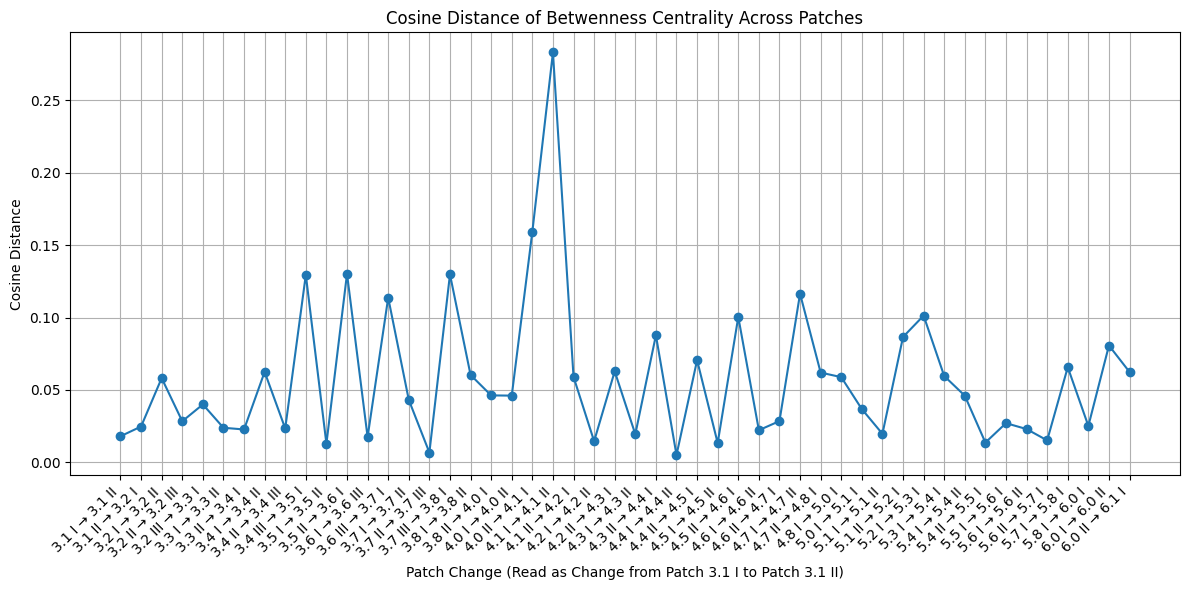

In [21]:
# Then because we are taking the change, we need a differenced
patches = eigenvector_df.columns
change_labels = [f"{patches[i]} → {patches[i+1]}" for i in range(len(patches)-1)]


plt.figure(figsize=(12, 6))
plt.plot(change_labels, betwenness_meta_dist, marker='o')

plt.title('Cosine Distance of Betwenness Centrality Across Patches')
plt.xlabel('Patch Change (Read as Change from Patch 3.1 I to Patch 3.1 II)')
plt.ylabel('Cosine Distance')
plt.grid(True)

# Apply Patch_Labeled as tick labels
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()
